# Integrate an ArcGIS Feature Service

This notebook integrates a public ArcGIS Feature Service into ARGUS using the new `%%skill-build` cell magic. The user writes no Python — paste the
service URL into a `%%skill-build` cell and ARGUS produces a queryable skill in the same cell.

We integrate the California wildfire perimeters service (CAL FIRE / NIFC / FIRIS), then query it in natural language to confirm it works end-to-end. A
follow-up query joins the new skill against a public-schools skill from GitHub, confirming the freshly-built skill behaves like any other skill in the
agent's toolset.

####   **Choose your language model**
  
  Argus is model-agnostic — you can plug in any of the major LLM providers and Argus will work. Pick whichever you have an API key for. To switch, comment out the active `LLM = {...}` block and uncomment the one you want.

  **This notebook defaults to GLM-5 via the National Research Platform** (free for NRP users, strong on scientific tool use). If you don't have NRP
  access, swap in OpenAI, Anthropic, or Google — they all work.

  **Before you run the cell: save your API key as a Colab Secret**

  Argus reads your API key from a Colab Secret, not from the notebook itself — that keeps the key out of your saved file and out of anyone you share the
  notebook with.

  1. Click the 🔑 key icon in the left sidebar (**Secrets**).
  2. Click **+ Add new secret**.
  3. Set the **Name** to match the `api_key_env` value in your `LLM` block:
     - `NRP_API_KEY` for GLM-5 on NRP
     - `OPENAI_API_KEY` for GPT-5.5
     - `ANTHROPIC_API_KEY` for Claude Sonnet/Opus
     - `GOOGLE_API_KEY` for Gemini

  4. Paste your key into the **Value** field.
  5. Toggle **Notebook access** on for this notebook.

  If the key isn't set (or notebook access is off), Argus will fail with an authentication error when it tries to call the model.

  ### Supported models

  | Provider | Models |
  |---|---|
  | OpenAI | GPT-5.5, GPT-5.4 |
  | Anthropic | Claude Opus 4.7, Opus 4.6 |
  | Google | Gemini 3.5 Flash |
  | Z.ai | GLM-5, GLM-5.1 |
  | Moonshot | Kimi-K2.6 |
  | MiniMax | MiniMax-M2.7 |
  | DeepSeek | DeepSeek-V4 Flash |

  Any model in this list should run Argus notebooks correctly. The four pre-configured blocks below are starter templates; for the others, follow the
  same `LLM = {...}` pattern with the right `model` and `api_key_env`.

In [1]:
# Use GLM-5 from National Research Platform
# LLM = {
#     "model": "glm-5",
#     "url": "https://ellm.nrp-nautilus.io/v1",
#     "api_key_env": "NRP_API_KEY",
# }

# Use GPT-5.5 from OpenAI
# LLM = {
#     "model": "gpt-5.5",
#     "api_key_env": "OPENAI_API_KEY",
# }

# Use Claude Sonnet 4.6 from Anthropic
# LLM = {
#     "model": "claude-sonnet-4-6",
#     "api_key_env": "ANTHROPIC_API_KEY",
#     "flavor": "anthropic",
# }

# Use Gemini 3.5 Flash from Google
# LLM = {
#     "model": "gemini-3.5-flash",
#     "api_key_env": "GOOGLE_API_KEY",
#     "flavor": "gemini",
# }

# Use GLM-5 from ZAI
LLM = {
    "model": "glm-5",
    "url": "https://api.z.ai/api/coding/paas/v4",
    "api_key_env": "ZAI_API_KEY",
}

#### **Install Argus from GitHub Repo**

In [2]:
import urllib.request
exec(urllib.request.urlopen(
    'https://raw.githubusercontent.com/klinucsd/sage/main/argus_colab/install.py'
).read().decode(), globals())

ARGUS bootstrap starting...
  ✓ Wrote LLM config to /root/.deepagents/config.toml (added default params for 1 ChatOpenAI provider(s))
  ✓ Loaded ZAI_API_KEY from Colab Secrets
  · Installing ARGUS dependencies (~30–90 s the first time)...
  ✓ ARGUS dependencies installed
  ✓ Downloaded sage_magic.py + sage_kernel_backend.py from main
  ✓ Installed 8 core skill(s) into /root/.deepagents/agent/skills: arcgis-feature-skill-builder, ndp-search, sage-bbox-map, sage-dropdown, sage-metrics, skillsmp, us-counties, us-states

ARGUS ready — %%ask, %%mcp, %%skill are registered.
  Provider: llm  ·  Model: llm:glm-5


In [3]:
%reset

**Sage reset.** Output folder cleared, history cleared.

_To also clear cell outputs: click **Edit → Clear all outputs** (in the Colab menu bar)._

In [4]:
%%skill-build
https://services1.arcgis.com/jUJYIo9tSA7EHvfZ/arcgis/rest/services/CA_Perimeters_NIFC_FIRIS_public_view/FeatureServer/0

I'll read the arcgis-feature-skill-builder meta-skill instructions first, since this URL is an ArcGIS Feature Service.

I've read the meta-skill. Let me set up my task tracking and start by fetching the service metadata.

Fetching the service metadata to understand the layer's fields, geometry, and capabilities.

The env var isn't set in this context. My working directory is the output dir. Let me fix the script to use it directly.

Metadata retrieved. This is a polygon layer (California fire perimeters), native SR 4269, 2000 record cap. Now I'll mark metadata done and run the batched categorical-field probe on the 6 candidate string fields.

...

I have the categorical data. The fields resolve as: `source` (5 codes, categorical), `type` (constant), `mission` (109 distinct, high cardinality), `incident_name`/`incident_number` (high cardinality identifiers), `displayStatus` (need to verify — I'll check it from the JSON). Let me read the tail of the probe results to confirm `displayStatus`.

`displayStatus` is cleanly categorical (Active/Inactive, 2 values). Let me pull the full `incident_name` enumeration (42 values, within the 2–50 band) so I can list exact fire names for querying.

I now have everything. Classification summary:
- **Categorical (full enumeration):** `source` (5 codes), `displayStatus` (2 codes), `incident_name` (42 fire names)
- **Constant:** `type` ("Heat Perimeter")
- **High-cardinality identifiers:** `mission` (109), `incident_number` (38 opaque codes)

Geometry is Polygon, native SR 4269 (NAD83), maxRecordCount 2000. Let me mark progress and write the SKILL.md.

Now I'll create the skill directory and write the full SKILL.md, with the canonical `get_features` loader verbatim and real codes from the probe.

✓ Built skill **ca-wildfire-perimeters** at `_skills_/ca-wildfire-perimeters/SKILL.md`.

Each row is a California wildfire — one mapped perimeter polygon per incident (136 perimeters at build time, polygon geometry, native NAD83). The skill exposes 14 fields and full code dictionaries for `source` (FIRIS / CAL FIRE / NIFC / USFS / WFIGS), `displayStatus` (Active / Inactive), and `incident_name` (42 fire names). Try queries like:

- **"show me all active California wildfires"**
- **"find California wildfires larger than 1000 acres"**
- **"list FIRIS-sourced wildfires in Southern California"**

The skill is available in the next `%%ask` cell.

I'll query the service for fires larger than 1000 acres using the skill's loader.

Running the query script.

Running without the timeout override.

Reading the full CSV summary to compile the complete list.

## California Wildfires > 1,000 Acres

I found **38 fire perimeters** larger than 1,000 acres in the dataset, totaling **135,618 acres** of mapped burned area. All are currently marked **Inactive** .

### Key statistics

- **Count** : 38 perimeters
- **Total burned area** : 135,618 acres
- **Mean size** : 3,569 acres · **Median** : 2,128 acres
- **Largest single perimeter** : SANTA ROSA at 18,379 acres

### Breakdown by source agency

| Source | Perimeters | Total acres |
|---|---|---|
| CAL FIRE INTEL FLIGHT DATA | 20 | 99,042 |
| FIRIS | 13 | 26,240 |
| NIFC | 2 | 5,089 |
| WFIGS | 2 | 3,194 |
| USFS | 1 | 2,053 |

### Breakdown by size class

| Size class | Count | Total acres |
|---|---|---|
| Mega (100k+ acres) | 0 | — |
| Large (10k–100k acres) | 4 | 59,861 |
| Major (5k–10k acres) | 1 | 5,690 |
| Significant (2.5k–5k acres) | 10 | 32,298 |
| Large (1k–2.5k acres) | 23 | 37,769 |

### All 38 fires (> 1,000 acres), ranked by size

| Rank | Incident | Acres | Source |
|---|---|---|---|
| 1 | SANTA ROSA | 18,379 | CAL FIRE INTEL FLIGHT DATA |
| 2 | SANTA ROSA ISLAND | 16,938 | CAL FIRE INTEL FLIGHT DATA |
| 3 | SANTA ROSA ISLAND | 14,519 | CAL FIRE INTEL FLIGHT DATA |
| 4 | SANTA ROSA ISLAND | 10,025 | CAL FIRE INTEL FLIGHT DATA |
| 5 | SANTA ROSA ISLAND | 5,690 | CAL FIRE INTEL FLIGHT DATA |
| 6 | (unnamed) | 4,176 | FIRIS |
| 7 | (unnamed) | 4,176 | FIRIS |
| 8 | RIVER | 3,535 | CAL FIRE INTEL FLIGHT DATA |
| 9 | RIVER | 3,535 | CAL FIRE INTEL FLIGHT DATA |
| 10 | SHORE | 3,277 | CAL FIRE INTEL FLIGHT DATA |
| 11 | Shore | 3,089 | NIFC |
| 12 | (unnamed) | 2,848 | FIRIS |
| 13 | BORDER 6 | 2,617 | CAL FIRE INTEL FLIGHT DATA |
| 14 | BORDER 6 | 2,525 | CAL FIRE INTEL FLIGHT DATA |
| 15 | (unnamed) | 2,520 | FIRIS |
| 16 | RIVER | 2,331 | CAL FIRE INTEL FLIGHT DATA |
| 17 | (unnamed) | 2,219 | FIRIS |
| 18 | SANDY | 2,183 | CAL FIRE INTEL FLIGHT DATA |
| 19 | SANDY | 2,141 | CAL FIRE INTEL FLIGHT DATA |
| 20 | SANDY | 2,115 | CAL FIRE INTEL FLIGHT DATA |
| 21 | (unnamed) | 2,053 | USFS |
| 22 | CANYON | 2,000 | WFIGS |
| 23 | CANYON | 2,000 | NIFC |
| 24 | SANDY | 1,698 | CAL FIRE INTEL FLIGHT DATA |
| 25 | WALTZ | 1,644 | CAL FIRE INTEL FLIGHT DATA |
| 26 | WALTZ | 1,644 | CAL FIRE INTEL FLIGHT DATA |
| 27 | BAIN | 1,497 | CAL FIRE INTEL FLIGHT DATA |
| 28 | BAIN | 1,456 | CAL FIRE INTEL FLIGHT DATA |
| 29 | (unnamed) | 1,408 | FIRIS |
| 30 | SANDY | 1,386 | FIRIS |
| 31 | BAIN | 1,375 | FIRIS |
| 32 | SANDY | 1,364 | FIRIS |
| 33 | MATEO | 1,292 | CAL FIRE INTEL FLIGHT DATA |
| 34 | (unnamed) | 1,280 | FIRIS |
| 35 | (unnamed) | 1,196 | FIRIS |
| 36 | (unnamed) | 1,194 | FIRIS |
| 37 | Mateo | 1,194 | WFIGS |
| 38 | (unnamed) | 1,098 | FIRIS |

### Notable observations

- **SANTA ROSA / SANTA ROSA ISLAND** dominate the top of the list, with the largest 5 perimeters (5.7k–18.4k acres) all from CAL FIRE intel flights.
- **CAL FIRE** is the leading contributor by area (99k of 136k acres) despite FIRIS contributing more individual perimeters overall in the full dataset.
- **SANDY, BAIN, RIVER, WALTZ, and CANYON** each appear multiple times — these reflect the same incident re-mapped across multiple flights/sources over time, which is why one named fire can have several rows.
- **11 of the 38 perimeters (29%) are unnamed** — mostly smaller FIRIS-sourced fires.


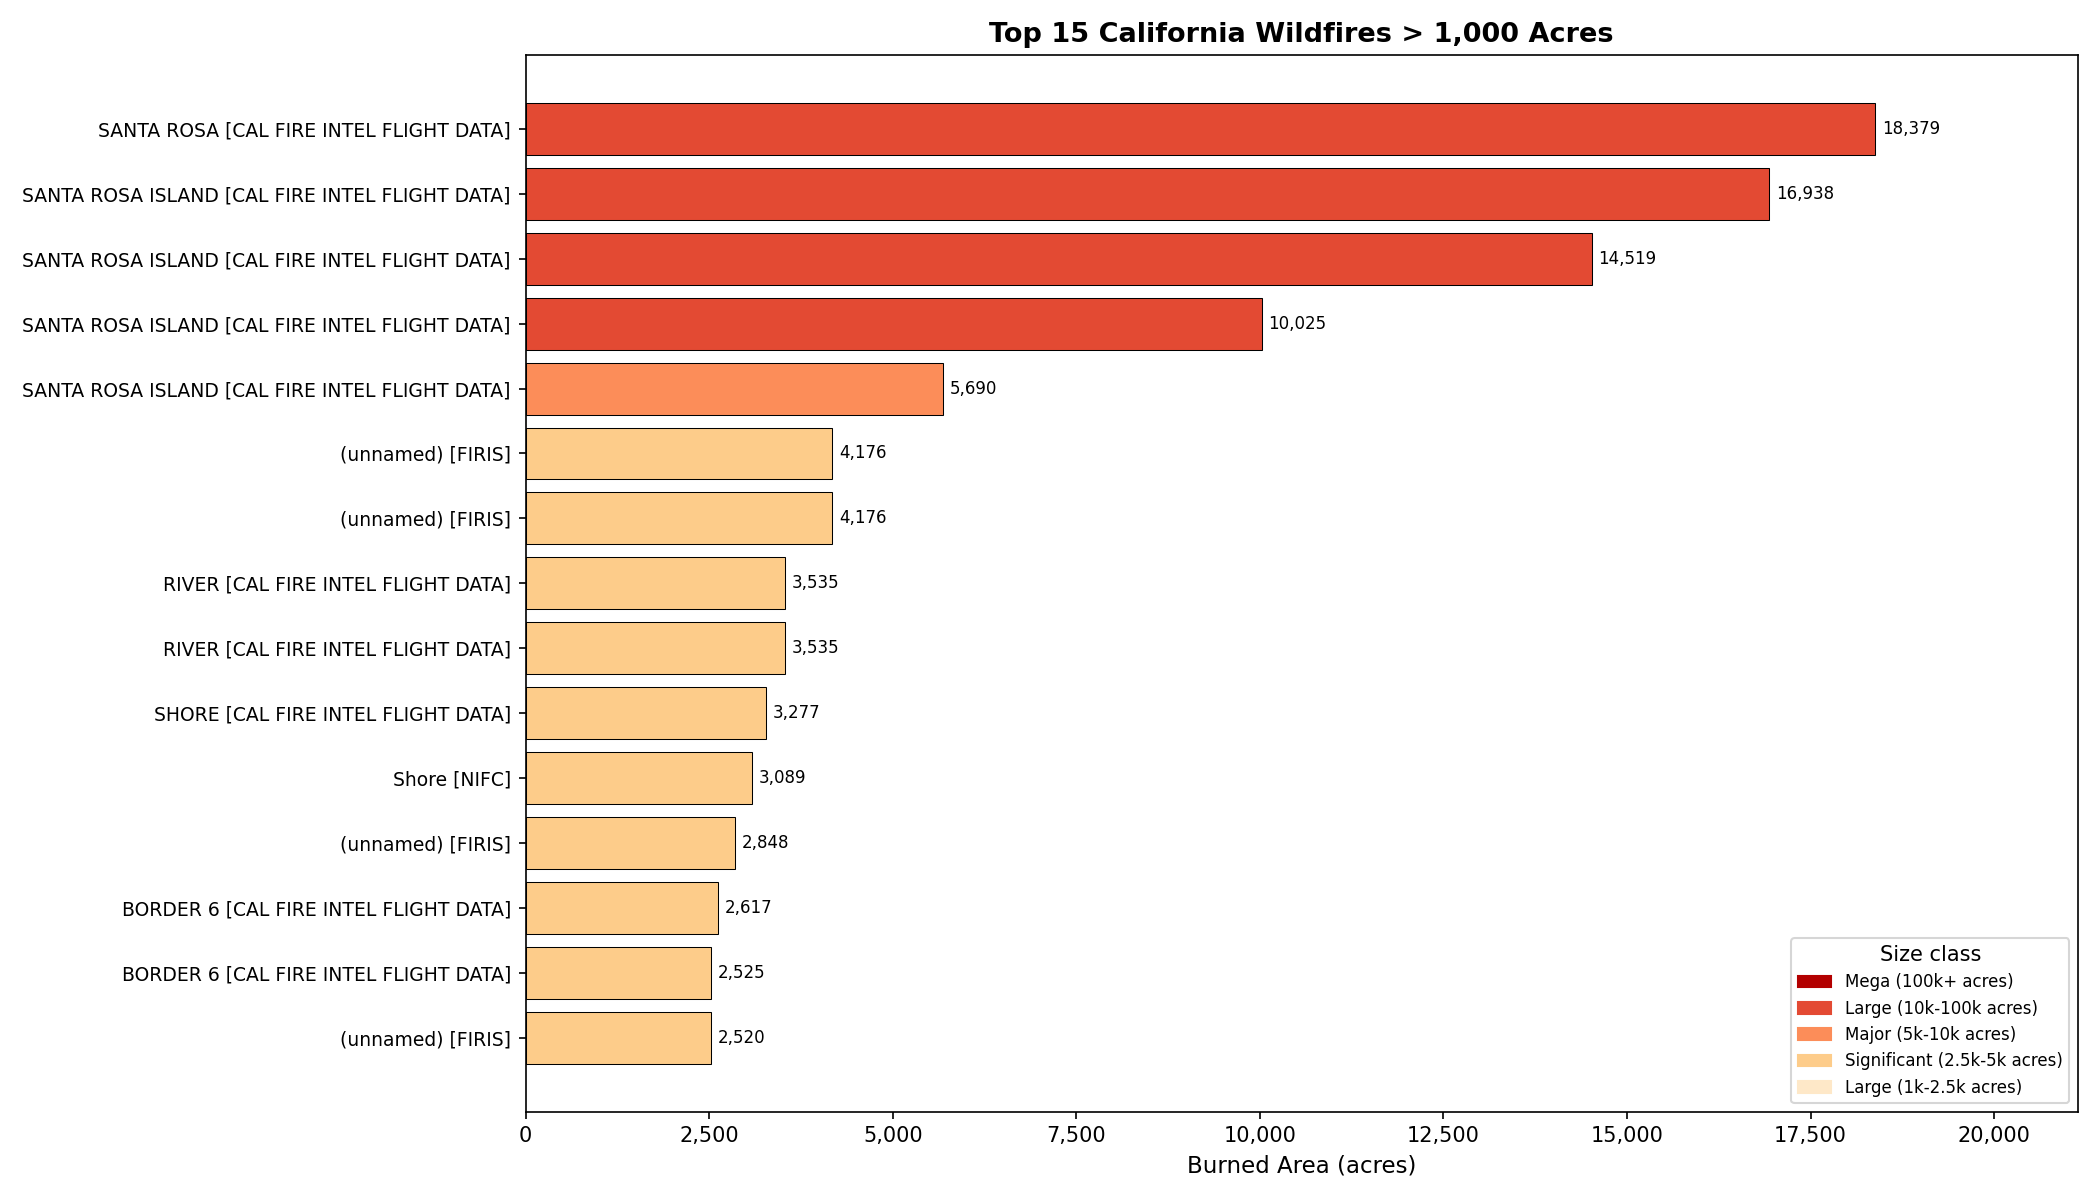

In [5]:
%%ask
Find all California wildfires > 1000 acres

In [6]:
%%skill
https://github.com/klinucsd/sage_skills/tree/main/society/public-schools

I'll read both skills to understand how to query wildfires and public schools, then find schools within one mile of the large fire perimeters.

Both skills are clear. My plan: fetch the 38 fire perimeters >1000 acres, query schools in an expanded bbox around each fire, then do a precise 1-mile buffer spatial join in a California projected CRS (EPSG:3310) to find schools actually within range.

Running the script to fetch fires, query schools, and perform the spatial join.

Retrying without the timeout parameter.

Got 17 unique schools near 12 fires. Let me update the todos and now create a bar chart plus inspect the CSV for the report.

The colormap references a `level_class` field, but the GeoJSON has `LEVEL_`. Let me normalize that field so the legend renders correctly.

All outputs are ready. Let me finalize the todos and compose the report.

## Public Schools Within 1 Mile of a California Wildfire > 1,000 Acres

I cross-referenced all 38 fire perimeters larger than 1,000 acres against the national public-schools feature service, then did a precise 1-mile buffer in the California Albers projection (EPSG:3310) so distances are accurate in metres.

**17 unique public schools** sit within one mile of one of these large-fire perimeters. They cluster around just **3 fire areas** — all in Ventura County (Simi Valley) and Riverside County (Moreno Valley / Jurupa Valley / Riverside).

### Headline numbers

- **17 schools** within 1 mile of a >1,000-acre fire perimeter
- **12 of 38** large fires (32%) have at least one nearby school
- **Closest school** : Rancho Verde High (Moreno Valley), **0.29 miles** from an unnamed 4,176-acre fire perimeter
- **Largest at-risk school** : Rancho Verde High with **2,371 students** ; Norte Vista High (2,144 students) is also at 0.64 miles

### At-risk schools by level

| School level | Schools | Total students |
|---|---|---|
| Elementary | 10 | ~5,378 |
| Middle | 4 | ~4,196 |
| High | 2 | ~4,515 |
| Not reported | 1 | — |

### The 17 at-risk schools (nearest fire per school), ranked by proximity

| School | Level | Enrollment | City | County | Nearest fire | Fire acres | Distance (mi) |
|---|---|---|---|---|---|---|---|
| Rancho Verde High | High | 2,371 | Moreno Valley | Riverside | (unnamed) | 4,176 | **0.29** |
| Crestview Elementary | Elementary | 288 | Simi Valley | Ventura | SANDY | 2,183 | 0.30 |
| Ridge Crest Elementary | Elementary | 592 | Moreno Valley | Riverside | (unnamed) | 4,176 | 0.37 |
| Hillside Middle | Middle | 935 | Simi Valley | Ventura | SANDY | 2,141 | 0.43 |
| Mountain View Elementary | Elementary | 355 | Simi Valley | Ventura | SANDY | 2,141 | 0.50 |
| Loma Vista Middle | Middle | 1,051 | Riverside | Riverside | BAIN | 1,375 | 0.53 |
| Rosemary Kennedy Elementary | Elementary | 461 | Riverside | Riverside | BAIN | 1,497 | 0.53 |
| Hollow Hills Elementary | Elementary | 688 | Simi Valley | Ventura | SANDY | 2,141 | 0.54 |
| Indian Hills Elementary | Elementary | 580 | Jurupa Valley | Riverside | BAIN | 1,497 | 0.54 |
| Landmark Middle | Middle | 1,217 | Moreno Valley | Riverside | (unnamed) | 4,176 | 0.55 |
| Lasselle Elementary | Elementary | 835 | Moreno Valley | Riverside | (unnamed) | 4,176 | 0.64 |
| Norte Vista High | High | 2,144 | Riverside | Riverside | BAIN | 1,456 | 0.64 |
| El Potrero Pre-School | Not reported | — | Moreno Valley | Riverside | (unnamed) | 4,176 | 0.69 |
| Terrace Elementary | Elementary | 659 | Riverside | Riverside | BAIN | 1,497 | 0.72 |
| Vista Verde Middle | Middle | 993 | Moreno Valley | Riverside | (unnamed) | 4,176 | 0.78 |
| Pedley Elementary | Elementary | 576 | Jurupa Valley | Riverside | BAIN | 1,497 | 0.81 |
| La Jolla Elementary | Elementary | 758 | Moreno Valley | Riverside | (unnamed) | 4,176 | 0.84 |

### Where the risk is concentrated

- **Moreno Valley / Riverside / Jurupa Valley (Riverside County)** — 13 of the 17 schools cluster here, threatened by one unnamed 4,176-acre perimeter and the three BAIN perimeters (1,375 / 1,456 / 1,497 acres).
- **Simi Valley (Ventura County)** — the remaining 4 schools, all within half a mile of multiple SANDY perimeters (~2,100 acres each).

### Data notes

- Distances are **edge-to-perimeter** (point-to-polygon), computed in EPSG:3310 and converted to miles — not straight-line to a centroid.
- The 38 fires include multiple perimeters for the same named incident (e.g., 8 SANDY, 4 BAIN entries) re-mapped across separate flights; each perimeter is treated as an independent hazard. A school near several SANDY entries is counted once (nearest perimeter shown).
- The remaining 26 large fires are all in remote/unpopulated terrain (Santa Rosa Island, desert, national forest) with no public school within the 1-mile search buffer.


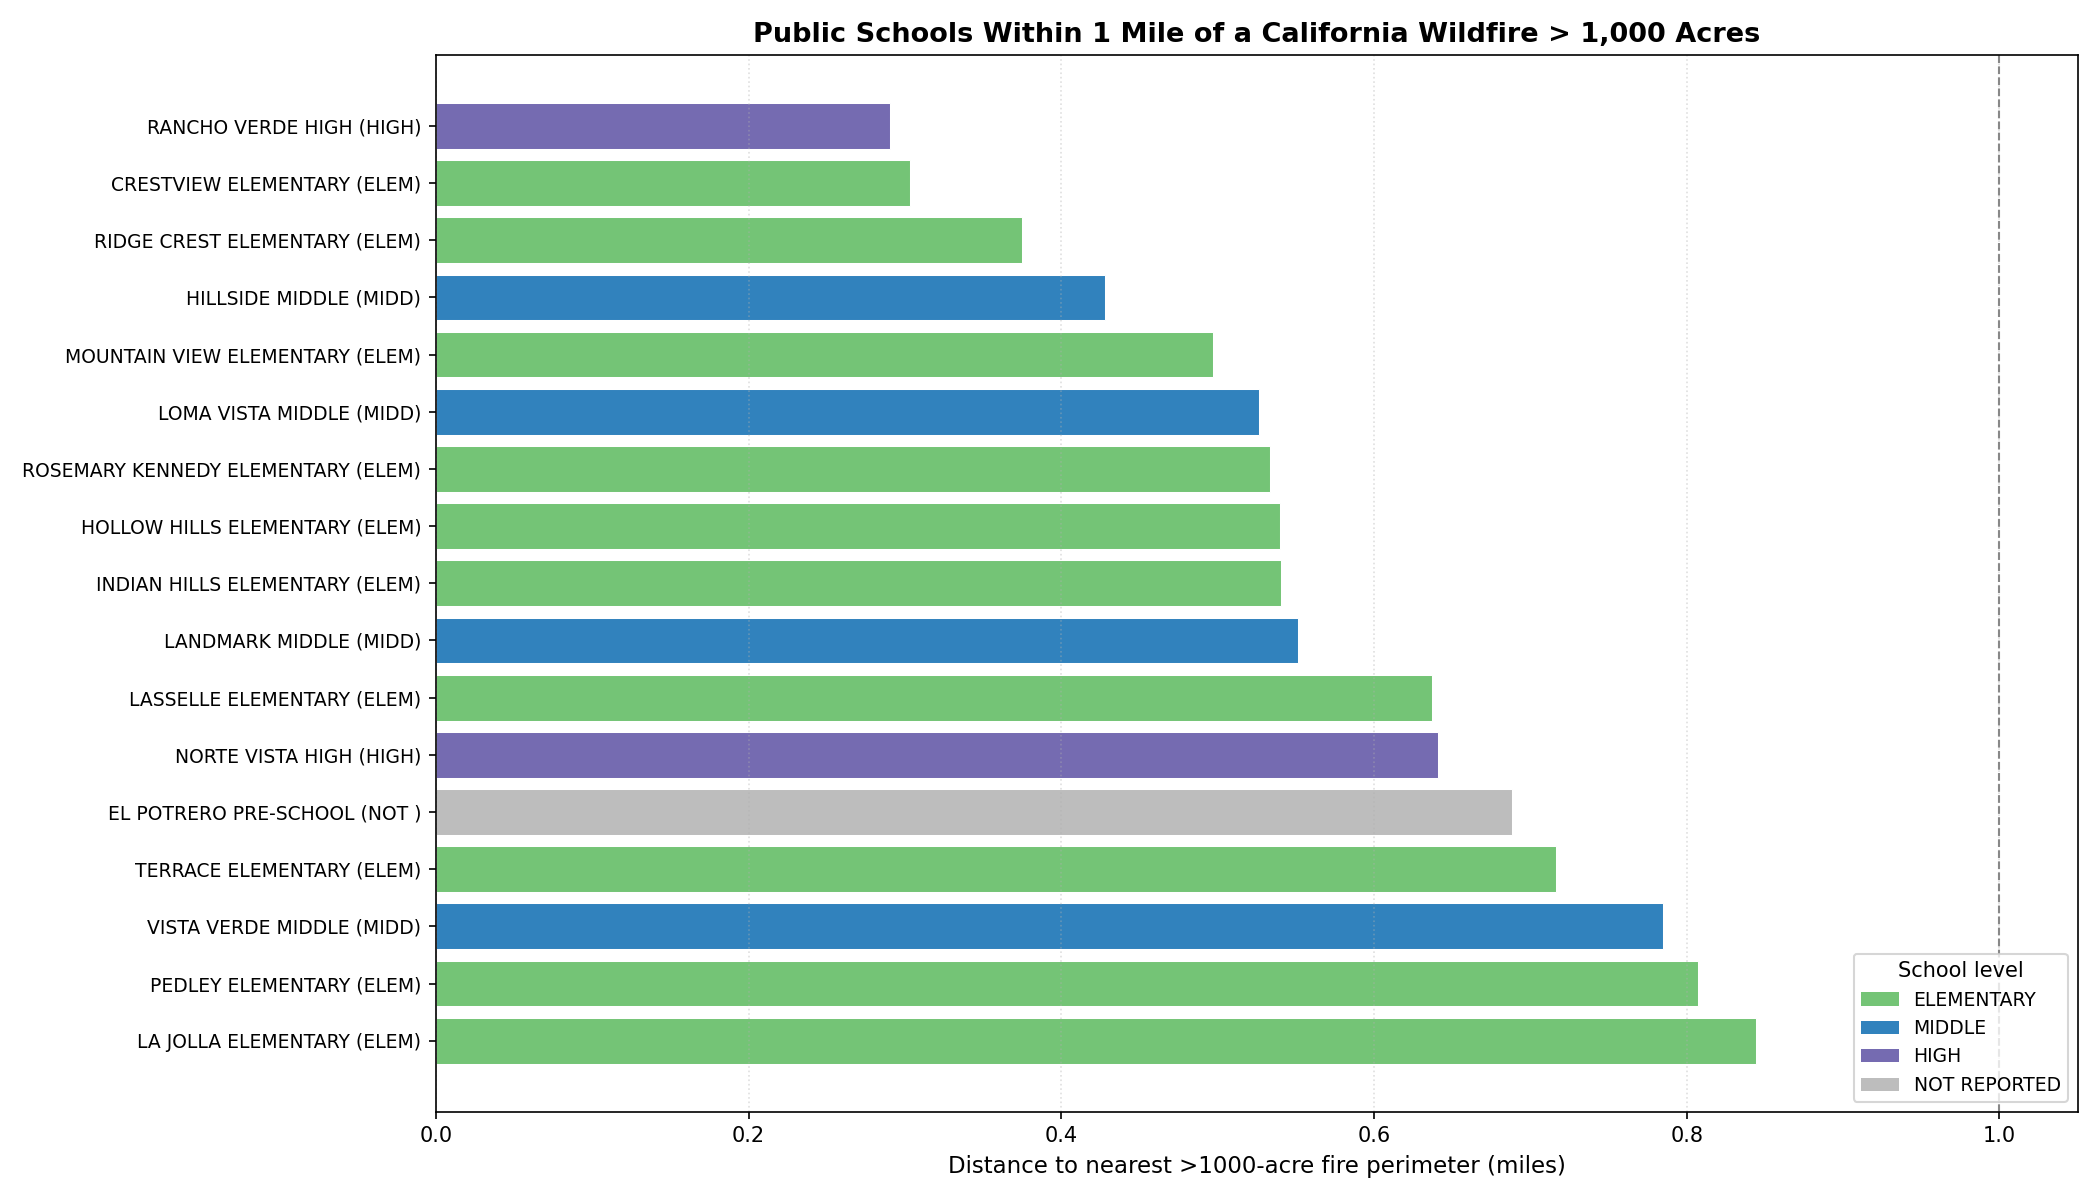

In [7]:
%%ask
Show public schools within one mile from a wildfire larger than 1,000 acres